In [483]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [485]:
data = pd.read_csv("call_log.csv")

In [487]:
data

,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type
0,4003253657,4012105215,27-FEB-23 01.20.27.168000000 PM,Call Center,NaN,Document Status,NaN,BIC/EBT
1,4003500855,4012169542,27-FEB-23 10.50.34.105000000 AM,Call Center,NaN,BIC Replacement,NaN,BIC/EBT
2,4003500855,4012169542,27-FEB-23 10.50.34.105000000 AM,Call Center,NaN,BIC Replacement,NaN,Verifications
3,4003258420,4012163729,27-FEB-23 03.20.43.392000000 PM,Call Center,NaN,Application Status,NaN,New Application
4,4004044552,4012230564,27-FEB-23 02.30.45.380000000 PM,Call Center,Determine Eligibility,None of the Above,Rerquesting Discontinuance,Discontinuance
...,...,...,...,...,...,...,...,...
61742,4005236661,4015371447,24-APR-24 10.42.44.478000000 AM,Call Center,NaN,None of the Above,verifications received,NaN
61743,4005251788,4015459327,24-APR-24 03.23.41.128000000 PM,Call Center,NaN,Benefits (NOA) - Other,Eligibility,Benefits Question
61744,4016319371,4024372254,24-APR-24 01.24.43.152000000 PM,Call Center,NaN,New Application,NaN,New Application
61745,4007903671,4020725990,24-APR-24 02.34.27.908000000 PM,Call Center,NaN,Document Status,NaN,NaN


In [489]:
data.describe()

,Case ID,Person ID
count,6.174700e+04,6.174700e+04
mean,4.004026e+09,4.000279e+09
std,1.933510e+06,1.648318e+08
min,4.003197e+09,6.286100e+04
25%,4.003354e+09,4.011726e+09
50%,4.003626e+09,4.012125e+09
75%,4.003856e+09,4.012540e+09
max,4.016322e+09,4.038614e+09


In [490]:
data.drop(data[data['Call Source'] == 'Outbound Interactive Voice Response (IVR) System'].index, inplace=True)
data = data.dropna(subset=['Call Source']).reset_index()

In [493]:
# Convert the Date/Time column to datetime
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d-%b-%y %I.%M.%S.%f %p')
data.head(10)

,index,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type
0,0,4003253657,4012105215,2023-02-27 13:20:27.168,Call Center,NaN,Document Status,NaN,BIC/EBT
1,1,4003500855,4012169542,2023-02-27 10:50:34.105,Call Center,NaN,BIC Replacement,NaN,BIC/EBT
2,2,4003500855,4012169542,2023-02-27 10:50:34.105,Call Center,NaN,BIC Replacement,NaN,Verifications
3,3,4003258420,4012163729,2023-02-27 15:20:43.392,Call Center,NaN,Application Status,NaN,New Application
4,4,4004044552,4012230564,2023-02-27 14:30:45.380,Call Center,Determine Eligibility,None of the Above,Rerquesting Discontinuance,Discontinuance
5,5,4003856550,4012250999,2023-02-27 09:00:33.780,Call Center,NaN,Change of Address,NaN,NaN
6,6,4003614723,4012256166,2023-02-27 13:45:56.076,Call Center,NaN,None of the Above,Managed Care,NaN
7,7,4003982285,4012257929,2023-02-27 09:19:52.734,Call Center,NaN,Benefits (NOA) - Denial or Discontinuance,NaN,Notice of Action
8,8,4003982285,4012257929,2023-02-27 09:19:52.734,Call Center,NaN,Benefits (NOA) - Denial or Discontinuance,NaN,New Application
9,9,4003310340,4012245165,2023-02-27 09:20:00.857,Call Center,NaN,Benefits (NOA) - Other,MC,NaN


In [494]:
data.describe()

,index,Case ID,Person ID,Date/Time
count,29347.000000,2.934700e+04,2.934700e+04,29347
mean,31045.012199,4.004219e+09,3.995525e+09,2023-09-08 15:41:41.328793344
min,0.000000,4.003197e+09,6.286100e+04,2023-02-27 09:00:33.780000
25%,16745.500000,4.003379e+09,4.011715e+09,2023-05-19 13:23:17.813000192
50%,31066.000000,4.003630e+09,4.012128e+09,2023-08-22 09:31:26.620000
75%,46019.500000,4.003865e+09,4.012568e+09,2024-01-02 15:52:49.615000064
max,61746.000000,4.016322e+09,4.038614e+09,2024-04-24 17:13:50.493000
std,17391.381103,2.326648e+06,1.886031e+08,NaN


### Explore the data

In [498]:
# Create a 'Month' column
data['Month'] = data['Date/Time'].dt.strftime('%Y-%m')

# Count the columns per date
data_by_month = data.groupby(['Month']).count().reset_index()
data_by_month.head()

,Month,index,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type
0,2023-02,118,118,118,118,118,10,118,40,92
1,2023-03,2748,2748,2748,2748,2748,156,2748,1072,2201
2,2023-04,2678,2678,2678,2678,2678,136,2678,1144,2078
3,2023-05,2656,2656,2656,2656,2656,162,2656,1137,1889
4,2023-06,2447,2447,2447,2447,2447,164,2447,1036,1578


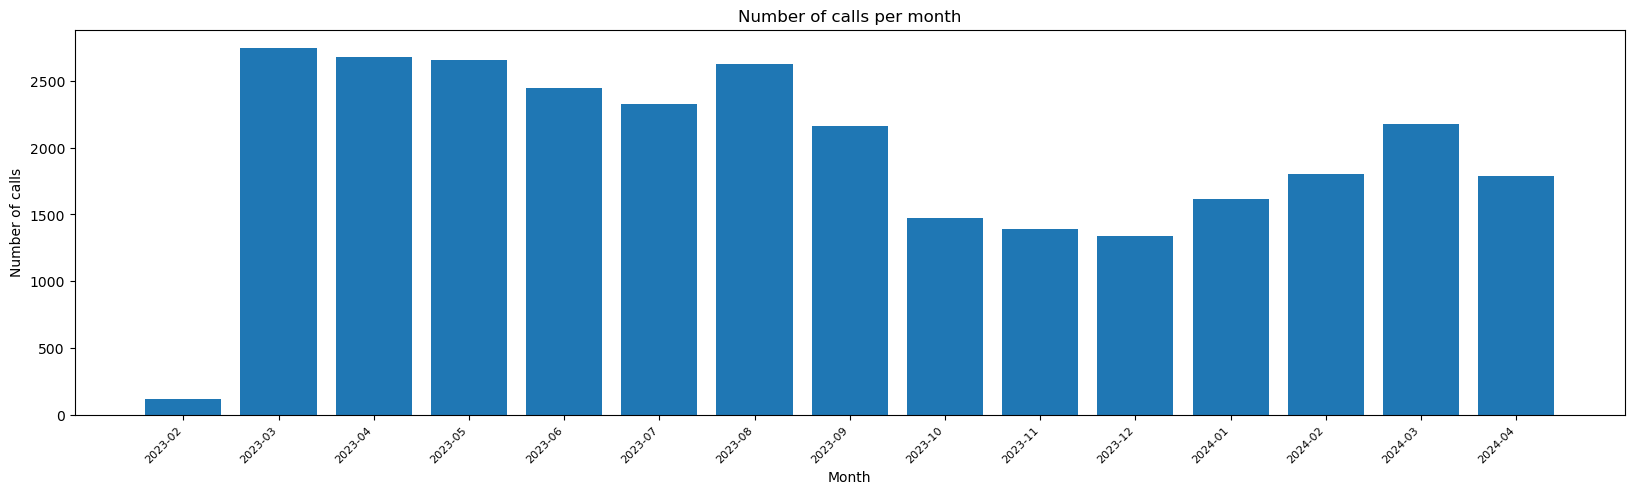

In [500]:
# Visualize the number of calls per month
plt.figure(figsize = (20, 5))
plt.bar(x=data_by_month['Month'],height=data_by_month['Person ID'])
plt.plot()

plt.xlabel("Month")
plt.ylabel("Number of calls")
plt.title("Number of calls per month")
plt.xticks(rotation = 45, horizontalalignment='right', fontsize=8)
plt.show()

array([[<Axes: title={'center': 'Primary Call Reason'}>]], dtype=object)

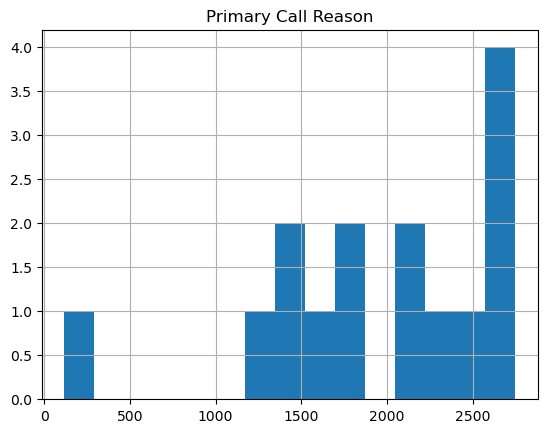

In [502]:
data_by_month[['Primary Call Reason']].hist(bins=15)

In [504]:
# Create a 'Date' column
data['Date'] = data['Date/Time'].dt.strftime('%Y-%m-%d')
data['Date'] = pd.to_datetime(data['Date'])

# Count the columns per date
data_by_date = data.groupby(['Date']).count().reset_index()
data_by_date

,Date,index,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type,Month
0,2023-02-27,55,55,55,55,55,5,55,15,41,55
1,2023-02-28,63,63,63,63,63,5,63,25,51,63
2,2023-03-01,117,117,117,117,117,22,117,43,95,117
3,2023-03-02,75,75,75,75,75,13,75,34,66,75
4,2023-03-03,112,112,112,112,112,3,112,50,88,112
...,...,...,...,...,...,...,...,...,...,...,...
287,2024-04-18,65,65,65,65,65,0,65,18,44,65
288,2024-04-19,116,116,116,116,116,7,116,61,74,116
289,2024-04-22,47,47,47,47,47,1,47,21,32,47
290,2024-04-23,94,94,94,94,94,6,94,33,57,94


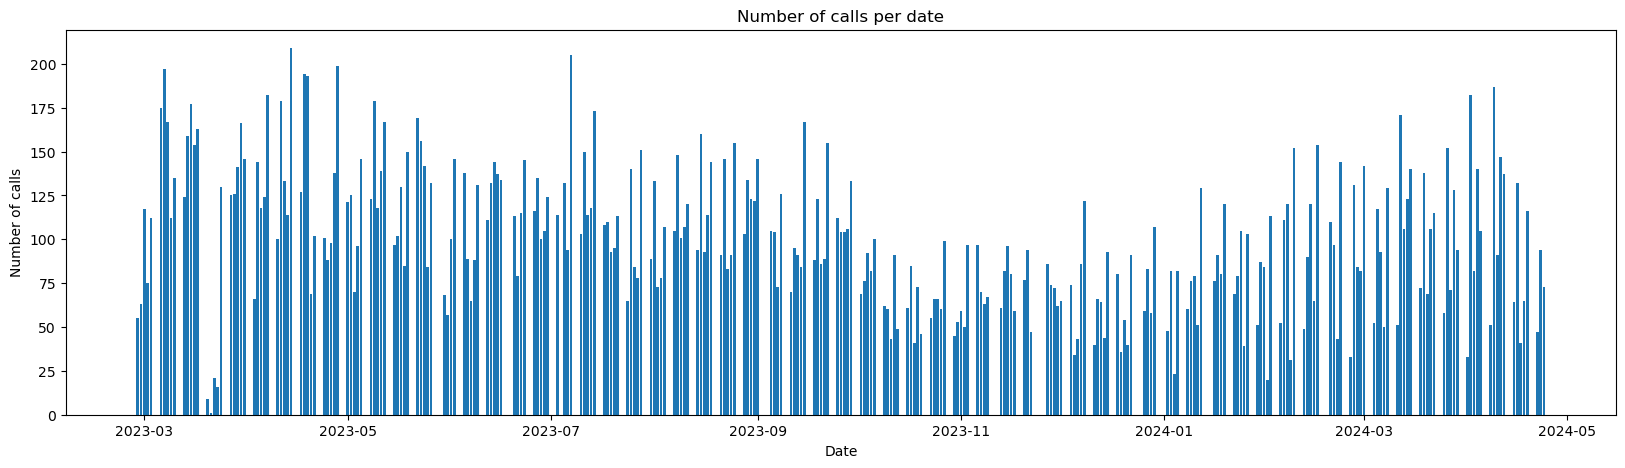

In [514]:
# Visualize the number of calls per date
plt.figure(figsize = (20, 5))
plt.bar(x=data_by_date['Date'],height=data_by_date['Person ID'])
plt.plot()

plt.xlabel("Date")
plt.ylabel("Number of calls")
plt.title("Number of calls per date")
plt.show()

In [508]:
data_by_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 292 non-null    datetime64[ns]
 1   index                292 non-null    int64         
 2   Case ID              292 non-null    int64         
 3   Person ID            292 non-null    int64         
 4   Date/Time            292 non-null    int64         
 5   Call Source          292 non-null    int64         
 6   Action Required      292 non-null    int64         
 7   Primary Call Reason  292 non-null    int64         
 8   Other Reason         292 non-null    int64         
 9   Call Log Type        292 non-null    int64         
 10  Month                292 non-null    int64         
dtypes: datetime64[ns](1), int64(10)
memory usage: 25.2 KB


array([[<Axes: title={'center': 'Primary Call Reason'}>]], dtype=object)

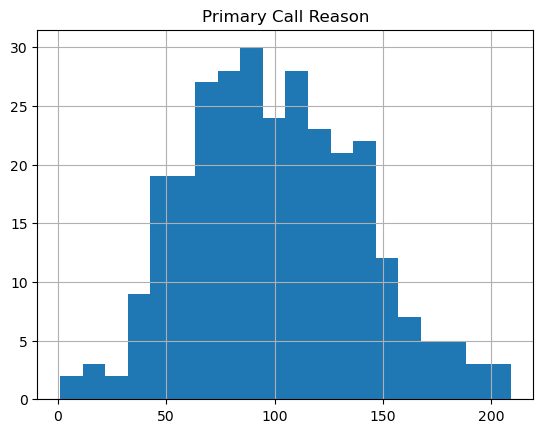

In [512]:
data_by_date[['Primary Call Reason']].hist(bins=20)

In [516]:
# Create a 'Day of Week' column
data['Day of Week'] = data['Date/Time'].dt.strftime('%w/%a')

# Count the columns per Day of Week
data_by_day_of_week = data.groupby(['Day of Week']).count().reset_index()
data_by_day_of_week

,Day of Week,index,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type,Month,Date
0,1/Mon,4448,4448,4448,4448,4448,299,4448,1698,2644,4448,4448
1,2/Tue,6634,6634,6634,6634,6634,238,6634,2930,4332,6634,6634
2,3/Wed,5662,5662,5662,5662,5662,483,5662,2319,3463,5662,5662
3,4/Thu,5152,5152,5152,5152,5152,174,5152,1921,3143,5152,5152
4,5/Fri,7451,7451,7451,7451,7451,433,7451,3168,4549,7451,7451


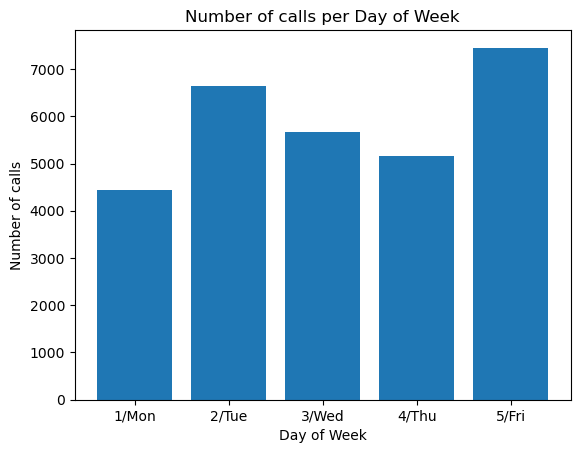

In [518]:
# Visualize the number of calls per Day of Week
# plt.figure(figsize = (10, 5))
plt.bar(x=data_by_day_of_week['Day of Week'],height=data_by_day_of_week['Person ID'])
plt.plot()

plt.xlabel("Day of Week")
plt.ylabel("Number of calls")
plt.title("Number of calls per Day of Week")
plt.show()

In [520]:
# Create a 'Week' column
data['Week'] = data['Date/Time'].dt.strftime('%Y-W%V')

# Count the columns per week
data_by_week = data.groupby(['Week']).count().reset_index()
data_by_week.head()

,Week,index,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type,Month,Date,Day of Week
0,2023-W09,422,422,422,422,422,48,422,167,341,422,422,422
1,2023-W10,786,786,786,786,786,19,786,303,634,786,786,786
2,2023-W11,777,777,777,777,777,44,777,322,626,777,777,777
3,2023-W12,177,177,177,177,177,35,177,67,149,177,177,177
4,2023-W13,704,704,704,704,704,20,704,253,543,704,704,704


In [522]:
# Count the unique column values per week
data_unique_by_week = data.groupby(['Week']).nunique().reset_index()
data_unique_by_week.head()

,Week,index,Case ID,Person ID,Date/Time,Call Source,Action Required,Primary Call Reason,Other Reason,Call Log Type,Month,Date,Day of Week
0,2023-W09,422,326,327,338,3,6,16,109,22,2,5,5
1,2023-W10,786,605,604,635,2,5,19,181,22,1,5,5
2,2023-W11,777,613,612,631,2,7,19,210,22,1,5,5
3,2023-W12,177,137,137,139,2,6,14,36,18,1,5,5
4,2023-W13,704,555,556,571,3,3,20,146,23,1,5,5


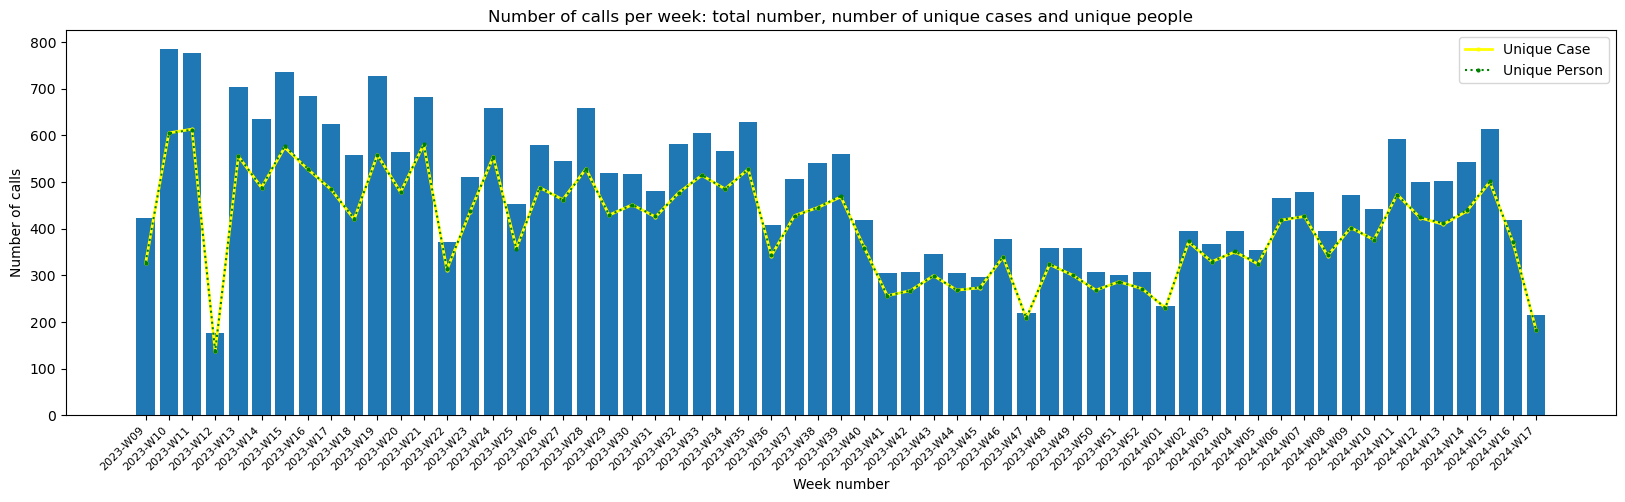

In [524]:
# Visualize the number of calls per week
plt.figure(figsize = (20, 5))
plt.bar(x=data_by_week['Week'],height=data_by_week['Person ID'])
plt.plot()

plt.plot(data_by_week['Week'], data_unique_by_week['Case ID'], color='yellow', marker='o', linewidth=2,  markersize=2)
plt.plot(data_by_week['Week'], data_unique_by_week['Person ID'], color='green', linestyle='dotted', marker='o', markersize=2)

plt.xlabel("Week number")
plt.ylabel("Number of calls")
plt.title("Number of calls per week: total number, number of unique cases and unique people")
plt.xticks(rotation = 45, horizontalalignment='right', fontsize=8)
plt.legend(['Unique Case', 'Unique Person']) 
plt.show()

array([[<Axes: title={'center': 'Primary Call Reason'}>]], dtype=object)

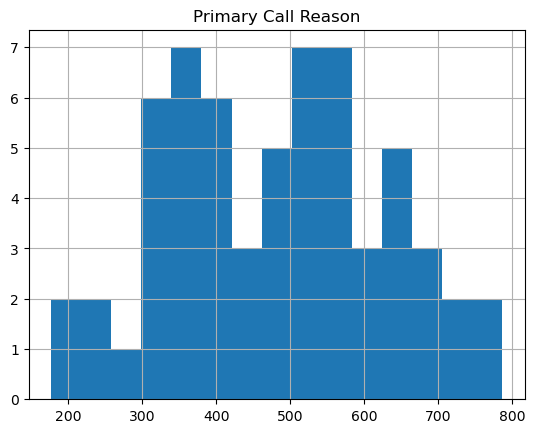

In [526]:
data_by_week[['Primary Call Reason']].hist(bins=15)

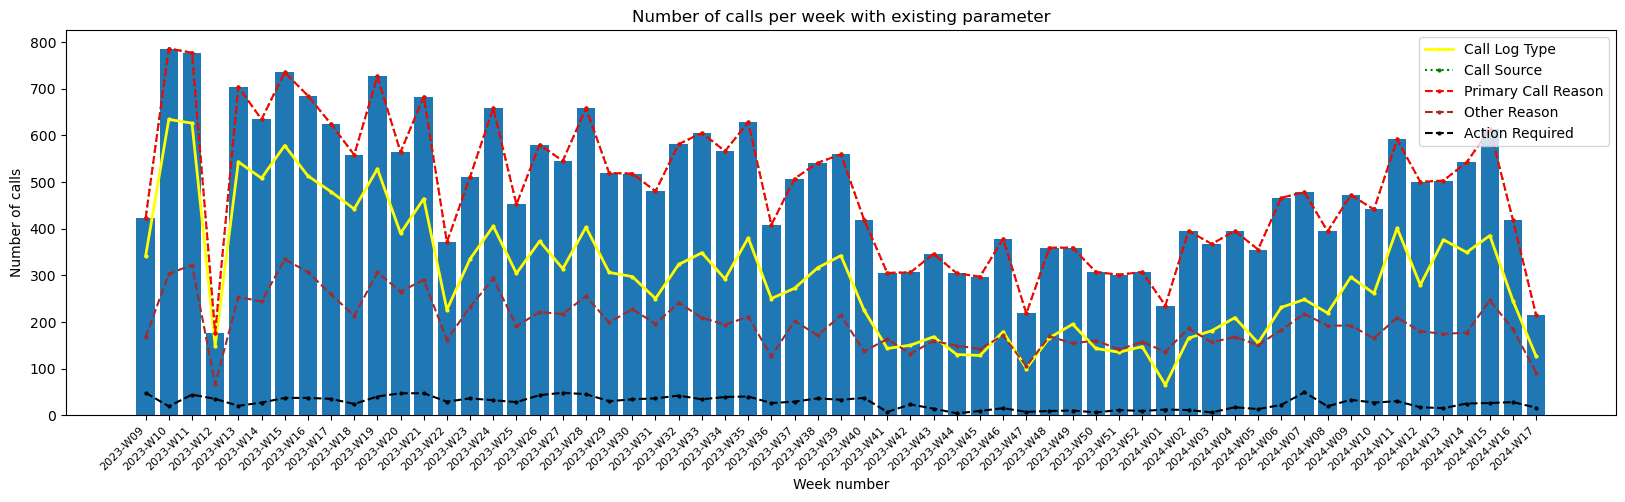

In [528]:
# Visualize the number of calls per week with existing call parameters
plt.figure(figsize = (20, 5))
plt.bar(x=data_by_week['Week'],height=data_by_week['Person ID'])
plt.plot()

plt.plot(data_by_week['Week'], data_by_week['Call Log Type'], color='yellow', marker='o', linewidth=2,  markersize=2)
plt.plot(data_by_week['Week'], data_by_week['Call Source'], color='green', linestyle='dotted', marker='o', markersize=2)
plt.plot(data_by_week['Week'], data_by_week['Primary Call Reason'], color='red', linestyle='dashed', marker='o', markersize=2)
plt.plot(data_by_week['Week'], data_by_week['Other Reason'], color='brown', linestyle='dashed', marker='o', markersize=2)
plt.plot(data_by_week['Week'], data_by_week['Action Required'], color='black', linestyle='dashed', marker='o', markersize=2)

plt.xlabel("Week number")
plt.ylabel("Number of calls")
plt.title("Number of calls per week with existing parameter")
plt.xticks(rotation = 45, horizontalalignment='right', fontsize=8)
plt.legend(['Call Log Type', 'Call Source', 'Primary Call Reason', 'Other Reason', 'Action Required']) 
plt.show()

### Explore `Primary Call Reason`

In [408]:
# Sample the existing `Primary Call Reason` records
data_pcr = data[['Case ID', 'Person ID', 'Date/Time', 'Primary Call Reason']]
data_pcr

,Case ID,Person ID,Date/Time,Primary Call Reason
0,4003253657,4012105215,2023-02-27 13:20:27.168,Document Status
1,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement
2,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement
3,4003258420,4012163729,2023-02-27 15:20:43.392,Application Status
4,4004044552,4012230564,2023-02-27 14:30:45.380,None of the Above
...,...,...,...,...
29342,4005236661,4015371447,2024-04-24 10:42:44.478,None of the Above
29343,4005251788,4015459327,2024-04-24 15:23:41.128,Benefits (NOA) - Other
29344,4016319371,4024372254,2024-04-24 13:24:43.152,New Application
29345,4007903671,4020725990,2024-04-24 14:34:27.908,Document Status


In [410]:
data_pcr = data_pcr.dropna().reset_index()
data_pcr

,index,Case ID,Person ID,Date/Time,Primary Call Reason
0,0,4003253657,4012105215,2023-02-27 13:20:27.168,Document Status
1,1,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement
2,2,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement
3,3,4003258420,4012163729,2023-02-27 15:20:43.392,Application Status
4,4,4004044552,4012230564,2023-02-27 14:30:45.380,None of the Above
...,...,...,...,...,...
29342,29342,4005236661,4015371447,2024-04-24 10:42:44.478,None of the Above
29343,29343,4005251788,4015459327,2024-04-24 15:23:41.128,Benefits (NOA) - Other
29344,29344,4016319371,4024372254,2024-04-24 13:24:43.152,New Application
29345,29345,4007903671,4020725990,2024-04-24 14:34:27.908,Document Status


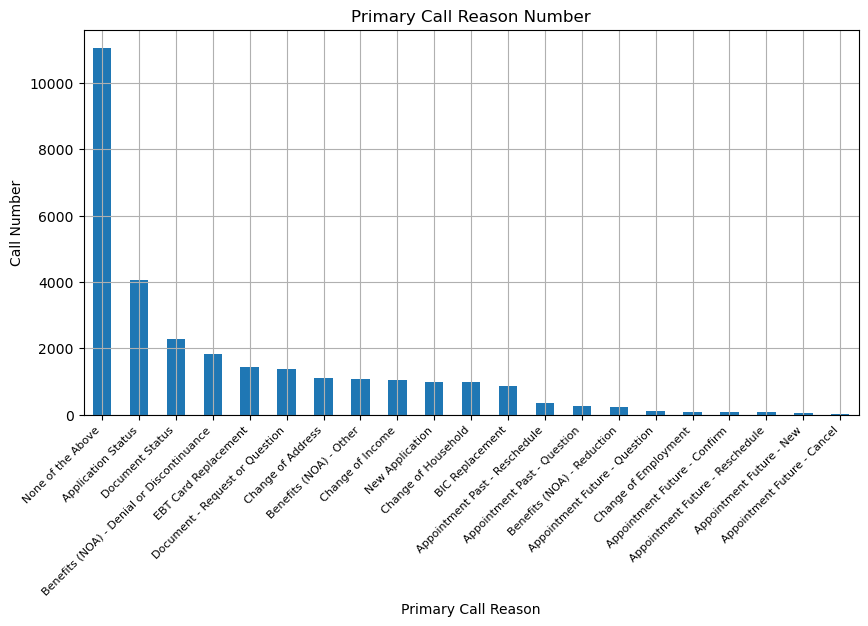

In [412]:
reason_counts = data_pcr['Primary Call Reason'].value_counts()

reason_counts.plot(kind='bar', figsize = (10, 5), grid=True)
plt.xlabel('Primary Call Reason')
plt.xticks(rotation = 45, horizontalalignment='right', fontsize=8)
plt.ylabel('Call Number')
plt.title('Primary Call Reason Number')
plt.show()

In [413]:
data_pcr['Primary Call Reason'].value_counts()

Primary Call Reason
None of the Above                            11053
Application Status                            4064
Document Status                               2275
Benefits (NOA) - Denial or Discontinuance     1818
EBT Card Replacement                          1428
Document - Request or Question                1383
Change of Address                             1118
Benefits (NOA) - Other                        1085
Change of Income                              1053
New Application                                991
Change of Household                            983
BIC Replacement                                868
Appointment Past - Reschedule                  353
Appointment Past - Question                    246
Benefits (NOA) - Reduction                     235
Appointment Future - Question                  123
Change of Employment                            73
Appointment Future - Confirm                    68
Appointment Future - Reschedule                 68
Appointment

In [416]:
# Label encoding: order matters (ordinal numeric labels)
# Convert 'Primary Call Reason' to numeric in the order of their number 
reason_dict = {
    'None of the Above': 1,
    'Application Status': 2,
    'Document Status': 3,
    'Benefits (NOA) - Denial or Discontinuance': 4,
    'EBT Card Replacement': 5,
    'Document - Request or Question': 6,
    'Change of Address': 7,
    'Benefits (NOA) - Other': 8,
    'Change of Income': 9,
    'Change of Household': 10,
    'New Application': 11,
    'BIC Replacement': 12,
    'Appointment Past - Reschedule': 13,
    'Appointment Past - Question': 14,
    'Benefits (NOA) - Reduction': 15,
    'Appointment Future - Question': 16,
    'Change of Employment': 17,
    'Appointment Future - Reschedule': 18,
    'Appointment Future - Confirm': 19,
    'Appointment Future - New': 20,
    'Appointment Future - Cancel': 21
}
data_pcr['Primary Call Reason Number'] = data_pcr['Primary Call Reason'].replace(reason_dict)
data_pcr.head()

,index,Case ID,Person ID,Date/Time,Primary Call Reason,Primary Call Reason Number
0,0,4003253657,4012105215,2023-02-27 13:20:27.168,Document Status,3
1,1,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement,12
2,2,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement,12
3,3,4003258420,4012163729,2023-02-27 15:20:43.392,Application Status,2
4,4,4004044552,4012230564,2023-02-27 14:30:45.380,None of the Above,1


In [418]:
# Label encoding: order doesn't matter (nominal numeric labels)
# Convert 'Primary Call Reason' to numeric
# data_pcr['Primary Call Reason Numeric'] = data_pcr['Primary Call Reason'].astype('category').cat.codes
# data_pcr

array([[<Axes: title={'center': 'Primary Call Reason Number'}>]],
      dtype=object)

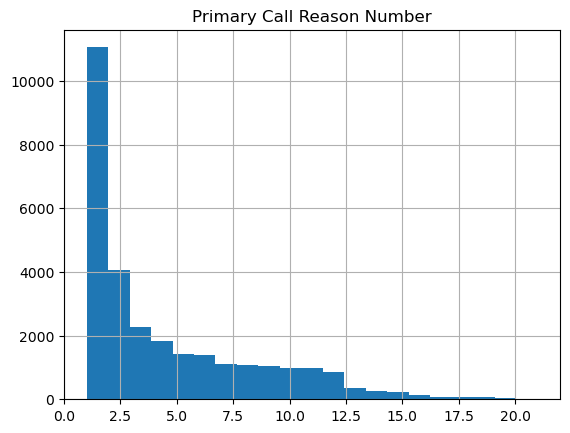

In [420]:
data_pcr.hist(column='Primary Call Reason Number', bins=21)

In [422]:
# Dummy encoding: order doesn't matter (creation of binary columns for each possible category contained in the variable)
# Convert `Primary Call Reason` to numeric data
# Create dummy variables with `Primary Call Reason` values
primary_call_reason_encoded = pd.get_dummies(data['Primary Call Reason'])

In [424]:
# Exclude 'None of the Above' Primary Call Reason
data_pcr.drop(data_pcr[data_pcr['Primary Call Reason'] == 'None of the Above'].index, inplace=True)
data_pcr

,index,Case ID,Person ID,Date/Time,Primary Call Reason,Primary Call Reason Number
0,0,4003253657,4012105215,2023-02-27 13:20:27.168,Document Status,3
1,1,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement,12
2,2,4003500855,4012169542,2023-02-27 10:50:34.105,BIC Replacement,12
3,3,4003258420,4012163729,2023-02-27 15:20:43.392,Application Status,2
5,5,4003856550,4012250999,2023-02-27 09:00:33.780,Change of Address,7
...,...,...,...,...,...,...
29341,29341,4015883260,4014905769,2024-04-24 15:52:51.772,Benefits (NOA) - Other,8
29343,29343,4005251788,4015459327,2024-04-24 15:23:41.128,Benefits (NOA) - Other,8
29344,29344,4016319371,4024372254,2024-04-24 13:24:43.152,New Application,11
29345,29345,4007903671,4020725990,2024-04-24 14:34:27.908,Document Status,3


In [426]:
# Create a 'Week' column
data_pcr['Week'] = data_pcr['Date/Time'].dt.strftime('%Y-W%V')

# Count the unique column values per week
data_pcr_by_week = data_pcr.groupby(['Week']).count().reset_index()
data_pcr_by_week

,Week,index,Case ID,Person ID,Date/Time,Primary Call Reason,Primary Call Reason Number
0,2023-W09,289,289,289,289,289,289
1,2023-W10,532,532,532,532,532,532
2,2023-W11,508,508,508,508,508,508
3,2023-W12,116,116,116,116,116,116
4,2023-W13,487,487,487,487,487,487
...,...,...,...,...,...,...,...
56,2024-W13,334,334,334,334,334,334
57,2024-W14,382,382,382,382,382,382
58,2024-W15,403,403,403,403,403,403
59,2024-W16,258,258,258,258,258,258


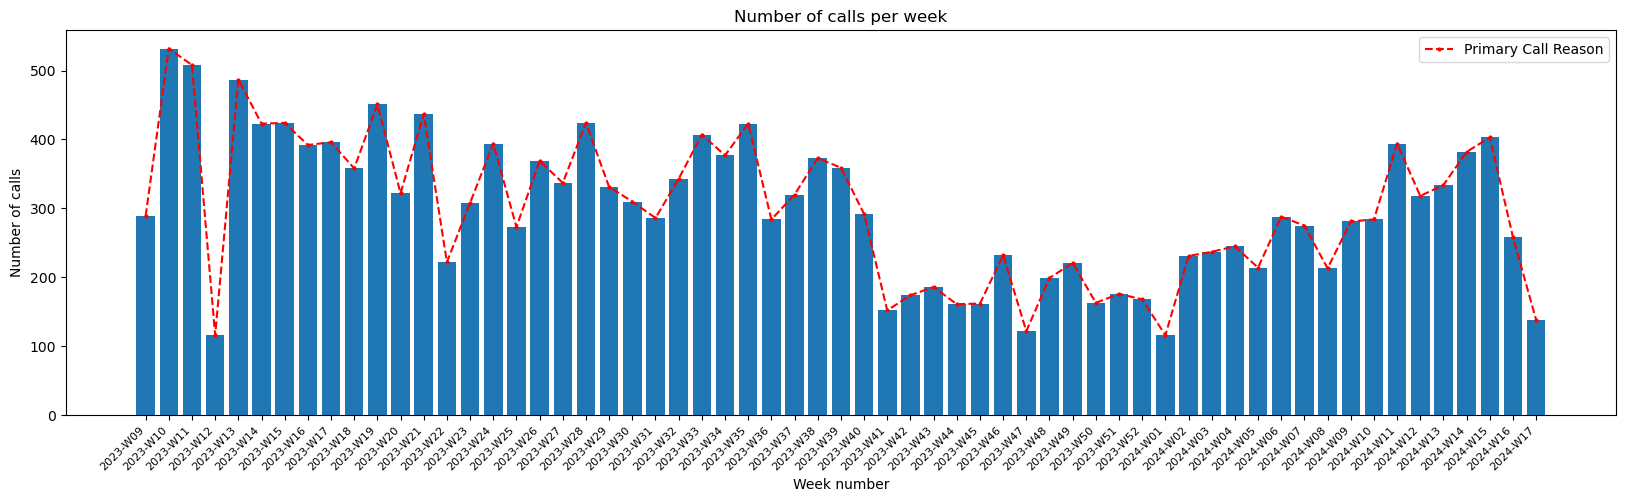

In [428]:
# Visualize the number of calls per week without 'None of the Above' Primary Call Reason 
plt.figure(figsize = (20, 5))
plt.bar(x=data_pcr_by_week['Week'],height=data_pcr_by_week['Person ID'])
plt.plot()

plt.plot(data_pcr_by_week['Week'], data_pcr_by_week['Primary Call Reason'], color='red', linestyle='dashed', marker='o', markersize=2)

plt.xlabel("Week number")
plt.ylabel("Number of calls")
plt.title("Number of calls per week")
plt.xticks(rotation = 45, horizontalalignment='right', fontsize=8)
plt.legend(['Primary Call Reason']) 
plt.show()

array([[<Axes: title={'center': 'Primary Call Reason'}>]], dtype=object)

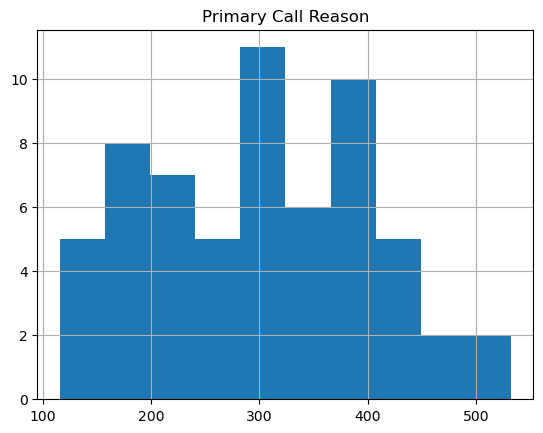

In [532]:
data_pcr_by_week[['Primary Call Reason']].hist(bins=10)

In [534]:
# Create a 'Date' column
data_pcr['Date'] = data_pcr['Date/Time'].dt.strftime('%Y-%m-%d')
data_pcr['Date'] = pd.to_datetime(data_pcr['Date'])

# Count the columns per date
data_pcr_by_date = data_pcr.groupby(['Date']).count().reset_index()
data_pcr_by_date

,Date,index,Case ID,Person ID,Date/Time,Primary Call Reason,Primary Call Reason Number,Week
0,2023-02-27,44,44,44,44,44,44,44
1,2023-02-28,44,44,44,44,44,44,44
2,2023-03-01,90,90,90,90,90,90,90
3,2023-03-02,44,44,44,44,44,44,44
4,2023-03-03,67,67,67,67,67,67,67
...,...,...,...,...,...,...,...,...
287,2024-04-18,47,47,47,47,47,47,47
288,2024-04-19,71,71,71,71,71,71,71
289,2024-04-22,26,26,26,26,26,26,26
290,2024-04-23,63,63,63,63,63,63,63


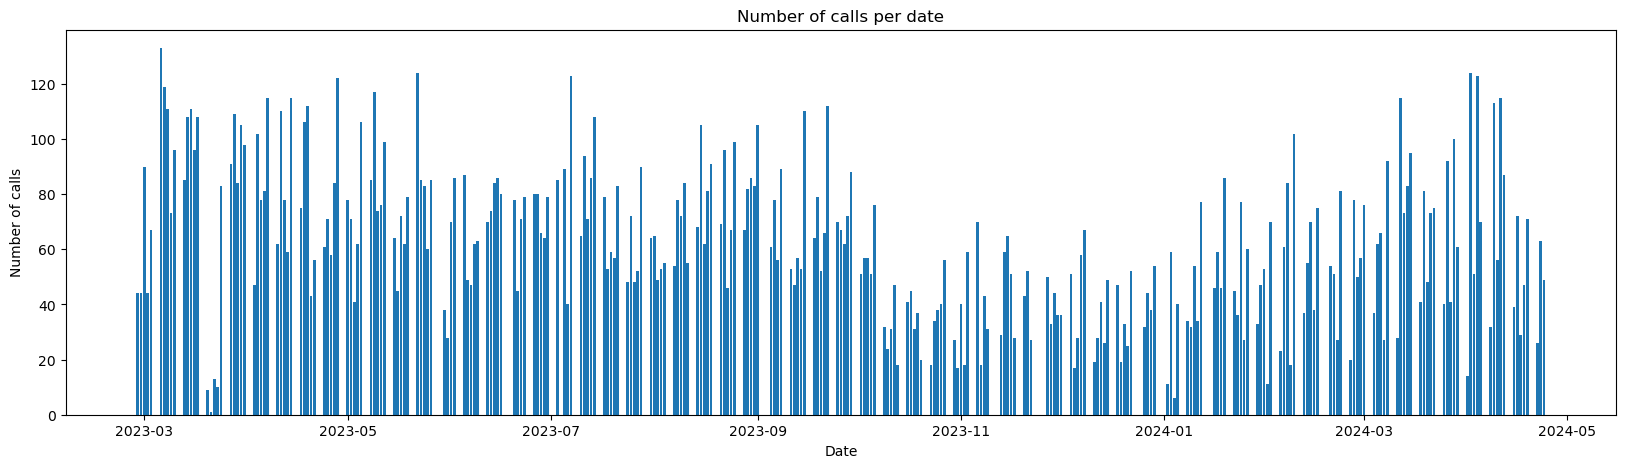

In [538]:
# Visualize the number of calls per date
plt.figure(figsize = (20, 5))
plt.bar(x=data_pcr_by_date['Date'],height=data_pcr_by_date['Person ID'])
plt.plot()

plt.xlabel("Date")
plt.ylabel("Number of calls")
plt.title("Number of calls per date")
plt.show()

array([[<Axes: title={'center': 'Date/Time'}>]], dtype=object)

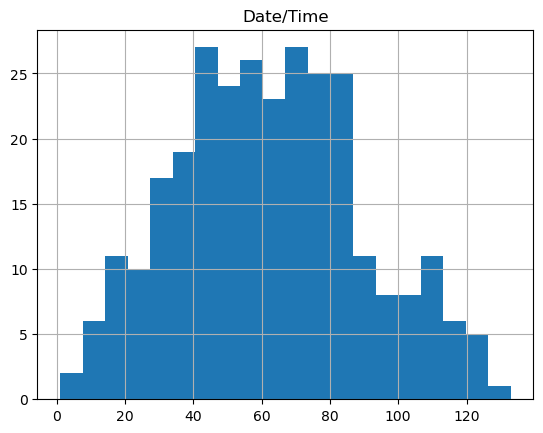

In [554]:
data_pcr_by_date[['Date/Time']].hist(bins=20)